In [183]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import re

In [184]:
# ========= 1. 實驗設定 (Configuration) =========

base_dir = r"C:\experiment\2D"

experiments = [
    {"file": os.path.join(base_dir, "t0145", "t0145.csv"), "color": "royalblue"  , "marker": "o", "group": "200PC"},
    {"file": os.path.join(base_dir, "t0148", "t0148.csv"), "color": "gray"       , "marker": "s", "group": "250PC"},
    {"file": os.path.join(base_dir, "t0137", "t0137.csv"), "color": "firebrick"  , "marker": "^", "group": "300PC"},
    {"file": os.path.join(base_dir, "t0149", "t0149.csv"), "color": "Olive"      , "marker": "D", "group": "350PC"},
    # {"file": os.path.join(base_dir, "t0141", "t0141.csv"), "color": "ForestGreen", "marker": "d", "group": "400PC"}
]

# 圖表 X 軸 (Normal Stress) 顯示範圍
xlim_min = 0
xlim_max = 10


In [185]:
# ========= 2. 資料處理 (Data Processing) =========

def extract_sigma(run_name):
    """ 從 run1_32MPa 這樣的字串中提取 32 作為數值 """
    match = re.search(r'_(\d+)MPa', str(run_name))
    if match:
        return float(match.group(1))
    return np.nan



def process_data(target_metric):
    """ 讀取 CSV 並計算各組在每個 sigma 下的 median 與 IQR """
    processed_data = []
    for exp in experiments:
        if not os.path.exists(exp['file']):
            print(f"找不到檔案: {exp['file']}")
            continue
            
        df = pd.read_csv(exp['file'])
        
        if 'skipped' in df.columns:
            df = df[df['skipped'] != 'YES'].copy()
            
        if 'k' in df.columns:
            df = df[pd.to_numeric(df['k'], errors='coerce') >= 0]
        
        if target_metric not in df.columns:
            continue
            
        # 提取 sigma
        df['sigma'] = df['Run'].apply(extract_sigma)
        df = df.dropna(subset=['sigma', target_metric])
        
        # 計算各個 sigma 的統計量
        stats = df.groupby('sigma')[target_metric].agg(
            median='median',
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75)
        ).reset_index()
        
        processed_data.append({
            'group': exp['group'],
            'color': exp['color'],
            'marker': exp['marker'],
            'stats': stats
        })
    return processed_data


In [186]:
# ========= 3. 繪製圖表函數 (Plotting Function) =========

def plot_metric(target_metric, title, ylabel):
    data_to_plot = process_data(target_metric)
    if not data_to_plot:
        print(f"找不到 {target_metric} 的資料")
        return
        
    fig, ax = plt.subplots(figsize=(10, 6))
    
    all_sigmas = []
    texts_to_draw = []
    for item in data_to_plot:
        stats = item['stats']
        sigmas = stats['sigma'].values
        medians = stats['median'].values
        yerr_lower = medians - stats['q1'].values
        yerr_upper = stats['q3'].values - medians
        
        all_sigmas.extend(sigmas)
        
        ax.errorbar(
            sigmas, medians, 
            yerr=[yerr_lower, yerr_upper], 
            fmt=item['marker'], color=item['color'], label=item['group'],
            markersize=10, capsize=5, 
            markerfacecolor='none', markeredgewidth=2,
            elinewidth=1.5, alpha=0.8, zorder=3
        )
        
        # Add trend line
        if len(sigmas) > 1:
            slope, intercept = np.polyfit(sigmas, medians, 1)
            x_line = np.array([sigmas.min(), sigmas.max()])
            y_line = slope * x_line + intercept
            ax.plot(x_line, y_line, color=item['color'], linestyle='--', linewidth=1.5, alpha=0.6, zorder=2)
            texts_to_draw.append({
                'x': x_line[-1] + 0.5,
                'y': y_line[-1],
                'text': f' m={slope:.3g}',
                'color': item['color']
            })

        
    # Draw non-overlapping trend line labels
    if texts_to_draw:
        y_min, y_max = ax.get_ylim() if ax.get_ylim() else (0, 1)
        y_range = y_max - y_min
        min_dist = y_range * 0.05
        
        texts_to_draw.sort(key=lambda t: t['y'])
        for i in range(1, len(texts_to_draw)):
            if texts_to_draw[i]['y'] - texts_to_draw[i-1]['y'] < min_dist:
                texts_to_draw[i]['y'] = texts_to_draw[i-1]['y'] + min_dist
                
        for t in texts_to_draw:
            ax.text(t['x'], t['y'], t['text'], color=t['color'], fontsize=11, fontweight='bold', va='center')

    ax.set_xlabel(r'Normal Stress $\sigma$ [MPa]', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.grid(True, alpha=0.6)
    ax.set_xlim(xlim_min, xlim_max)
    
    if all_sigmas:
        ax.set_xticks(np.unique(all_sigmas))
        
    # 圖例放外面
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout()
    plt.show()


In [ ]:
# ========= 4. 以群組為 X 軸的繪圖函數 (Group X-Axis Plotting Function) =========

# Sigma -> (顏色, 標記) 映射
SIGMA_STYLE = {
    1.0: ("royalblue",    "o"),
    2.0: ("forestgreen",  "s"),
    4.0: ("firebrick",    "^"),
    8.0: ("purple",       "D"),
}

def plot_metric_by_group(target_metric, title, ylabel):
    """以實驗群組為 X 軸（順序與 experiments 設定相同），不同 sigma 為系列繪圖。"""
    # 從 experiments 設定推導群組順序（保留使用者定義的順序）
    group_order = [exp["group"] for exp in experiments]
    group_xval  = {g: i for i, g in enumerate(group_order)}

    data_to_plot = process_data(target_metric)
    if not data_to_plot:
        print(f"找不到 {target_metric} 欄位")
        return

    # 收集所有出現的 sigma 值
    all_sigmas = set()
    for item in data_to_plot:
        all_sigmas.update(item["stats"]["sigma"].values)
    unique_sigmas = sorted(all_sigmas)

    fig, ax = plt.subplots(figsize=(10, 6))
    texts_to_draw = []

    for sigma in unique_sigmas:
        x_vals, y_vals, yerr_lo, yerr_hi = [], [], [], []

        for item in data_to_plot:
            group = item["group"]
            if group not in group_xval:
                continue
            stats = item["stats"]
            row = stats[stats["sigma"] == sigma]
            if row.empty:
                continue
            x_vals.append(group_xval[group])
            med = row["median"].values[0]
            q1  = row["q1"].values[0]
            q3  = row["q3"].values[0]
            y_vals.append(med)
            yerr_lo.append(med - q1)
            yerr_hi.append(q3 - med)

        if not x_vals:
            continue

        x_arr = np.array(x_vals)
        y_arr = np.array(y_vals)
        color, marker = SIGMA_STYLE.get(sigma, ("gray", "o"))
        label = f"{sigma:.0f} MPa"

        ax.errorbar(
            x_arr, y_arr,
            yerr=[np.array(yerr_lo), np.array(yerr_hi)],
            fmt=marker, color=color, label=label,
            markersize=10, capsize=5,
            markerfacecolor="none", markeredgewidth=2,
            elinewidth=1.5, alpha=0.8, zorder=3
        )

        # 趨勢線（需要至少 2 個點）
        if len(x_arr) > 1:
            slope, intercept = np.polyfit(x_arr, y_arr, 1)
            x_line = np.array([x_arr.min(), x_arr.max()])
            y_line = slope * x_line + intercept
            ax.plot(x_line, y_line, color=color, linestyle="--", linewidth=1.5, alpha=0.6, zorder=2)
            texts_to_draw.append({
                "x": x_line[-1] + 0.1,
                "y": y_line[-1],
                "text": f" m={slope:.3g}",
                "color": color
            })

    # 調整趨勢線標籤避免重疊
    if texts_to_draw:
        y_min, y_max = ax.get_ylim()
        y_range = y_max - y_min if y_max != y_min else 1
        min_dist = y_range * 0.05
        texts_to_draw.sort(key=lambda t: t["y"])
        for i in range(1, len(texts_to_draw)):
            if texts_to_draw[i]["y"] - texts_to_draw[i-1]["y"] < min_dist:
                texts_to_draw[i]["y"] = texts_to_draw[i-1]["y"] + min_dist
        for t in texts_to_draw:
            ax.text(t["x"], t["y"], t["text"], color=t["color"],
                    fontsize=11, fontweight="bold", va="center")

    ax.set_xlabel("Experimental Group", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.set_xlim(-0.5, len(group_order) - 0.5)
    ax.set_xticks(range(len(group_order)))
    ax.set_xticklabels(group_order)
    ax.grid(True, alpha=0.6)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
    plt.tight_layout()
    plt.show()


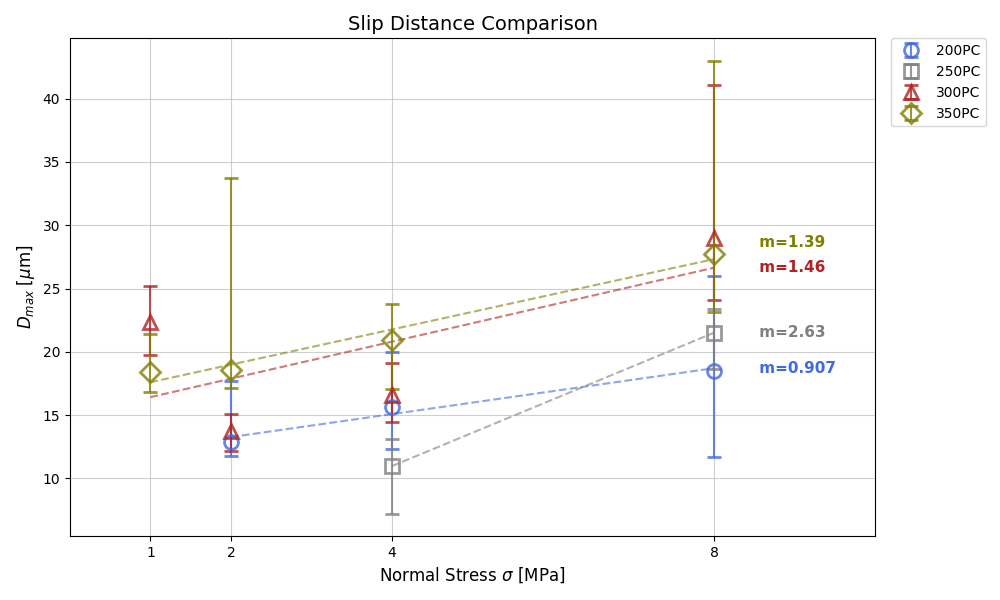

In [188]:
# === 繪製 D_max 圖 ===
plot_metric('D_max', 'Slip Distance Comparison', r'$D_{max}$ [$\mu$m]')


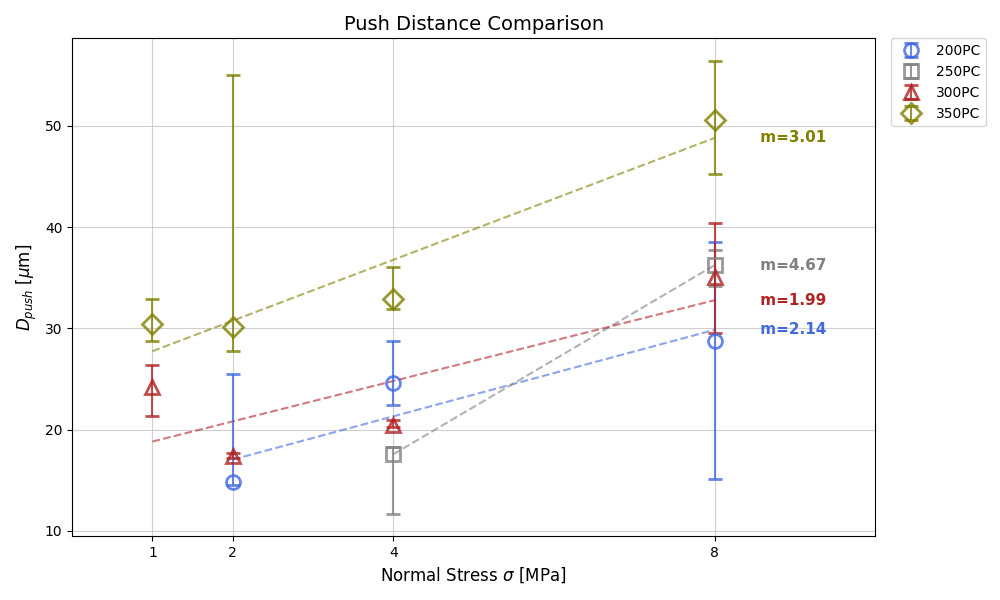

In [189]:
# === 繪製 D_Push 圖 ===
plot_metric('D_Push', 'Push Distance Comparison', r'$D_{push}$ [$\mu$m]')

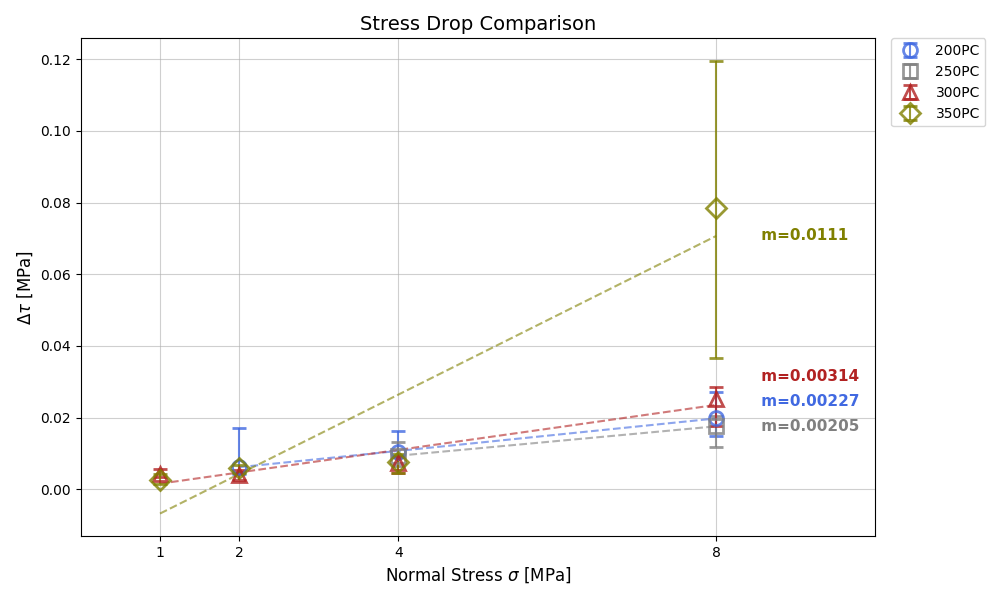

In [190]:
# === 繪製 Delta Tau 圖 ===
plot_metric('delta_tau', 'Stress Drop Comparison', r'$\Delta\tau$ [MPa]')


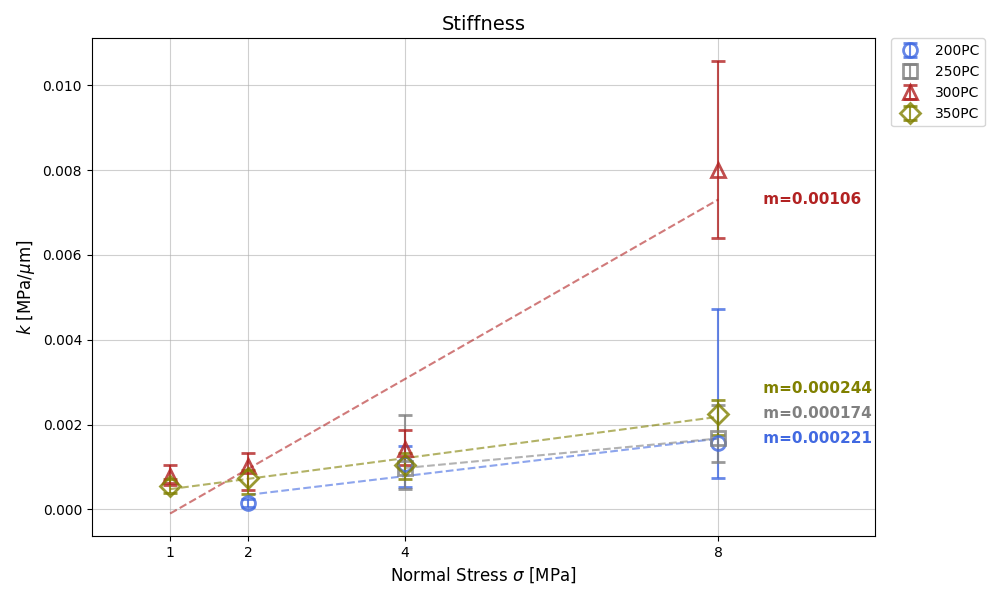

In [191]:
# === 繪製 Stiffness k 圖 ===
plot_metric('k', 'Stiffness', r'$k$ [MPa/$\mu$m]')


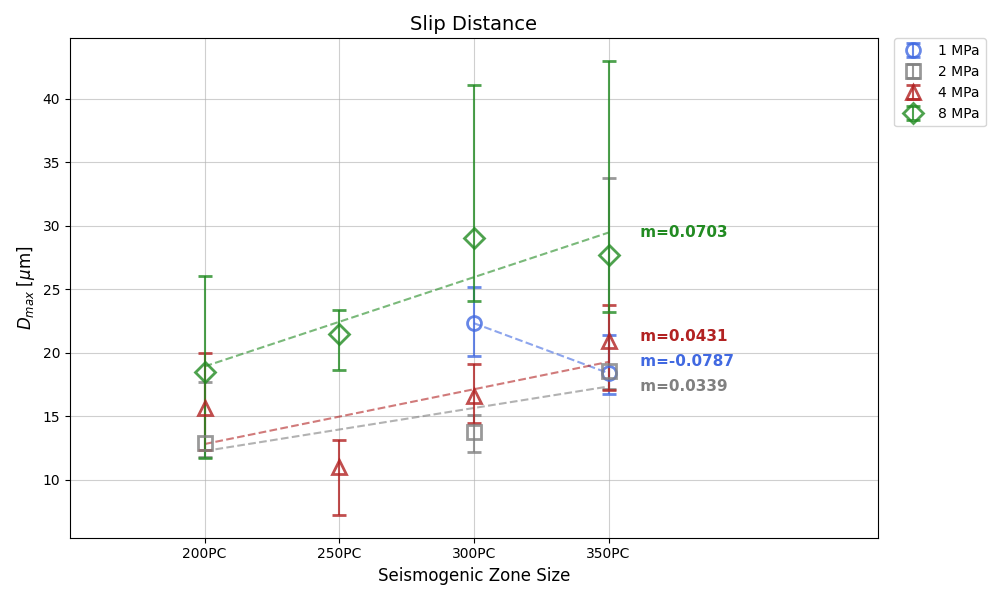

In [192]:
# === 以群組為 X 軸：D_max 圖 ===
plot_metric_by_group('D_max', 'Slip Distance', r'$D_{max}$ [$\mu$m]')


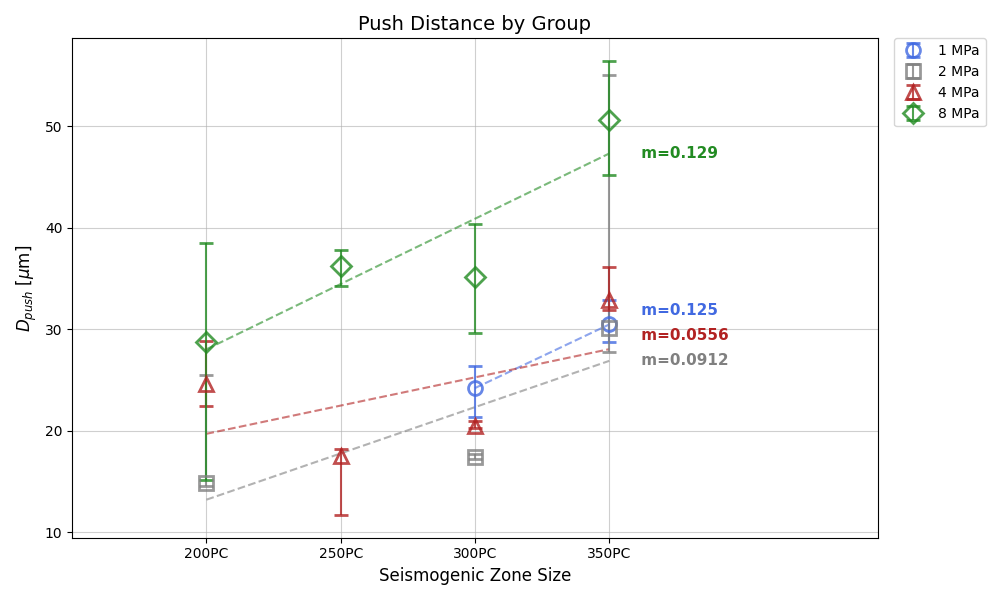

In [193]:
# === 以群組為 X 軸：D_Push 圖 ===
plot_metric_by_group('D_Push', 'Push Distance by Group', r'$D_{push}$ [$\mu$m]')


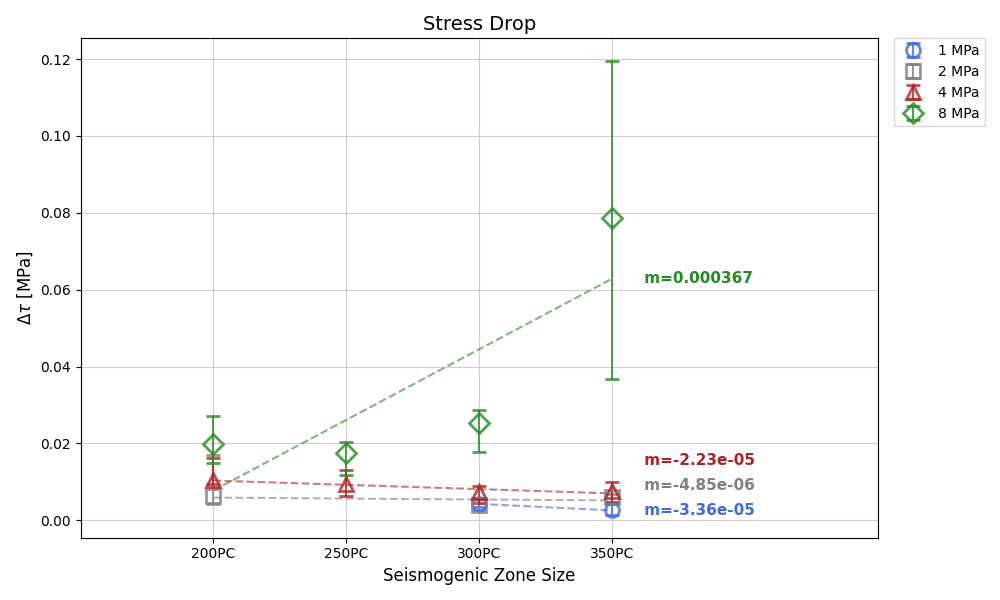

In [194]:
# === 以群組為 X 軸：Stress Drop 圖 ===
plot_metric_by_group('delta_tau', 'Stress Drop', r'$\Delta\tau$ [MPa]')


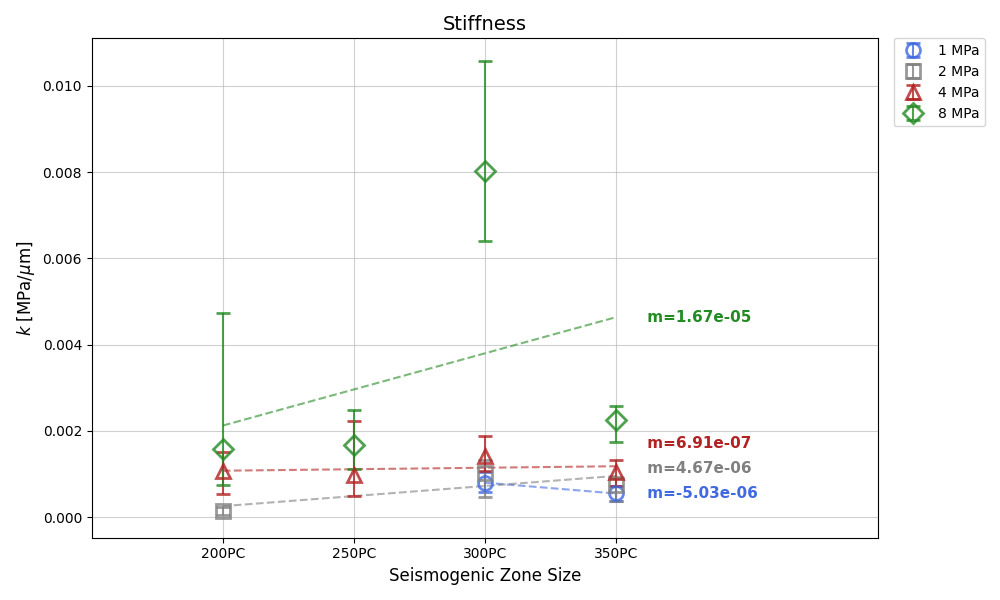

In [195]:
# === 以群組為 X 軸：Stiffness k 圖 ===
plot_metric_by_group('k', 'Stiffness', r'$k$ [MPa/$\mu$m]')
